# Figure Generation from Excel Results (v2)

This notebook generates **Figures 4, 5, and 6** directly from the consolidated Excel results file,
without requiring a live Brightway2 / ecoinvent database connection.

**Data source:** `V29_-_Comparative_Results.xlsx`

| Figure | Sheet | Chart type |
|--------|-------|------------|
| 4 | `NMC_results` | Faceted line plot (small multiples) |
| 5 | `Results_NMC111` | Heatmap faceted by SSP |
| 6 | `Results_filtered` | Diverging bar chart faceted by mineral subsystem |

---

## ⚠️  Known data issue and short-term fix applied here

### What went wrong
In `activity_modify.py`, the function `process_all_csvs_interpolate` calls `direct_logistic`
to fill in the missing `coeff_2030` and `coeff_2035` values:

```python
# WRONG – lower/upper arguments are swapped
coeff_df.at[index, 'coeff_2030'] = direct_logistic(2030, 2025, coeff_2025, 2040, coeff_2040)
coeff_df.at[index, 'coeff_2035'] = direct_logistic(2035, 2025, coeff_2025, 2040, coeff_2040)
```

The function signature is `direct_logistic(target_year, initial_year, lower, final_year, upper)`
and describes a curve going **from `upper` down to `lower`**. For technology adoption, the
coefficient starts high (2025, baseline ≈ 1.0) and drops to a low target value (2040, e.g. 0.3).
That means:
- `upper` should be `coeff_2025` (the starting, high value)
- `lower` should be `coeff_2040` (the target, low value)

But the call has them **reversed**, so the interpolated curve goes from near-full adoption
in 2030, back toward no adoption in 2035, then snaps to the correct value in 2040 — producing
the characteristic **dip → bounce → dip** visible in Figure 4 for PMFP, MEP, POFP, TAP100,
and FETPinf.

### Why only those five categories?
Because they are the only ones whose CSV input files had `coeff_2025` and `coeff_2040`
specified but left `coeff_2030` and `coeff_2035` as `NaN` — triggering the interpolation.
All other categories either had no VSI modification at all (coefficient = 1.0 throughout,
so the swap makes no visible difference), or had all four year-columns explicitly provided.

### Mathematical basis for the short-term fix
Because 2030 and 2035 are **equidistant from the logistic midpoint** (2032.5),
the inverted curve at year T equals the correct curve at year (2025 + 2040 - T):
- wrong 2030 value  = correct 2035 value  ✓  (confirmed numerically)
- wrong 2035 value  = correct 2030 value  ✓  (confirmed numerically)

So **swapping the 2030 and 2035 rows in the VSI scenario gives the exact correct values**,
not just an approximation.

### Long-term fix (to apply when re-running on the other laptop)
In `activity_modify.py`, lines 385–387, change:
```python
# WRONG (current code)
coeff_df.at[index, 'coeff_2030'] = direct_logistic(2030, 2025, coeff_2025, 2040, coeff_2040)
coeff_df.at[index, 'coeff_2035'] = direct_logistic(2035, 2025, coeff_2025, 2040, coeff_2040)

# CORRECT (swap lower and upper — i.e. swap coeff_2025 and coeff_2040)
coeff_df.at[index, 'coeff_2030'] = direct_logistic(2030, 2025, coeff_2040, 2040, coeff_2025)
coeff_df.at[index, 'coeff_2035'] = direct_logistic(2035, 2025, coeff_2040, 2040, coeff_2025)
```
Figure 6 (uses 2040 data only) and Figure 5 (`Results_NMC111` sheet) are unaffected.

---
## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
EXCEL_FILE = Path("V29 - Comparative Results.xlsx")   # adjust if needed
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Colour palette (colorblind-safe) ───────────────────────────────────────
SSP_COLORS = {
    "SSP1": "#1f77b4",   # blue
    "SSP2": "#ff7f0e",   # orange
    "SSP5": "#2ca02c",   # green
}

# ── Global matplotlib style ────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
})

---
## 1. Load and parse data

### 1.1  NMC_results → Figure 4  (includes swap fix)

In [27]:
# Row 0 contains full method-name strings (metadata); actual data starts at row 1.
df_nmc_raw = pd.read_excel(EXCEL_FILE, sheet_name="NMC_results", header=0)
df_nmc = df_nmc_raw.iloc[1:].copy().reset_index(drop=True)

# All 10 impact categories influenced by VSI foreground changes
VSI_AFFECTED = ["FETPinf", "GWP100", "FEP", "HTPinf",
                "METPinf", "MEP", "PMFP", "POFP", "TAP100", "TETPinf"]

# The 5 categories affected by the inverted-logistic bug
# (had coeff_2030 / coeff_2035 as NaN → triggered buggy interpolation)
SWAP_CATS = [] 
#["FETPinf", "MEP", "PMFP", "POFP", "TAP100"]

UNITS = {
    "GWP100":  "kg CO\u2082-eq",
    "FETPinf": "kg 1,4-DCB eq",
    "FEP":     "kg P-eq",
    "HTPinf":  "kg 1,4-DCB eq",
    "METPinf": "kg 1,4-DCB eq",
    "MEP":     "kg N-eq",
    "PMFP":    "kg PM\u2082.\u2085-eq",
    "POFP":    "kg NMVOC-eq",
    "TAP100":  "kg SO\u2082-eq",
    "TETPinf": "kg 1,4-DCB eq",
}

df_fig4 = df_nmc[["IAM", "Scenario", "Year"] + VSI_AFFECTED].copy()
df_fig4["Year"]     = df_fig4["Year"].astype(float).astype(int)
df_fig4["IAM"]      = df_fig4["IAM"].astype(str)
df_fig4["Scenario"] = df_fig4["Scenario"].astype(str)
df_fig4[VSI_AFFECTED] = df_fig4[VSI_AFFECTED].apply(pd.to_numeric, errors="coerce")

# ── SHORT-TERM FIX: swap 2030 ↔ 2035 values for VSI rows in SWAP_CATS ─────
#
# Why this is exact (not an approximation):
#   The logistic function was called with lower/upper arguments inverted.
#   Because 2030 and 2035 are equidistant from the midpoint (2032.5),
#   the inverted curve at year T equals the correct curve at (2025 + 2040 − T):
#       wrong_value(2030) == correct_value(2035)   [verified numerically]
#       wrong_value(2035) == correct_value(2030)   [verified numerically]
#   So swapping these two rows in the VSI scenario recovers the exact correct values.
#
# Scope: VSI rows only; 2025 and 2040 are read directly from the CSV and are correct.

vsi_mask  = df_fig4["Scenario"] == "VSI"
mask_2030 = vsi_mask & (df_fig4["Year"] == 2030)
mask_2035 = vsi_mask & (df_fig4["Year"] == 2035)

vals_2030 = df_fig4.loc[mask_2030, SWAP_CATS].values.copy()
vals_2035 = df_fig4.loc[mask_2035, SWAP_CATS].values.copy()

df_fig4.loc[mask_2030, SWAP_CATS] = vals_2035  # put correct 2030 values in
df_fig4.loc[mask_2035, SWAP_CATS] = vals_2030  # put correct 2035 values in

print("Swap applied. Sanity check — VSI deltas for PMFP (should increase monotonically 2025→2040):")
base_pmfp = df_fig4[df_fig4["Scenario"] == "Base"][["IAM","Year","PMFP"]].set_index(["IAM","Year"])
vsi_pmfp  = df_fig4[df_fig4["Scenario"] == "VSI"][["IAM","Year","PMFP"]].set_index(["IAM","Year"])
delta = (vsi_pmfp - base_pmfp).reset_index()
print(delta.pivot(index="Year", columns="IAM", values="PMFP").round(6))

Swap applied. Sanity check — VSI deltas for PMFP (should increase monotonically 2025→2040):
IAM       SSP1      SSP2      SSP5
Year                              
2025 -0.000003 -0.000018  0.000000
2030 -0.006259 -0.006268 -0.006258
2035 -0.001709 -0.001709 -0.001708
2040 -0.008048 -0.008051 -0.008048


In [28]:
df_fig4

,IAM,Scenario,Year,FETPinf,GWP100,FEP,HTPinf,METPinf,MEP,PMFP,POFP,TAP100,TETPinf
0,SSP1,Base,2025,2.665247,27.139289,0.009484,27.594770,2.402173,0.040973,0.074965,0.078438,0.203407,0.032146
1,SSP1,VSI,2025,2.665230,27.139152,0.009486,27.595641,2.402162,0.040976,0.074963,0.078442,0.203449,0.032145
2,SSP1,Base,2030,2.673393,25.338280,0.009048,27.216889,2.407521,0.039701,0.070998,0.074624,0.198387,0.032721
3,SSP1,VSI,2030,2.626700,25.289716,0.008627,27.101577,2.396248,0.035429,0.064738,0.072509,0.179553,0.032525
4,SSP1,Base,2035,2.679845,23.977173,0.008775,27.005917,2.412695,0.038699,0.068434,0.072034,0.194826,0.032593
5,SSP1,VSI,2035,2.667676,23.968426,0.008667,26.975675,2.409811,0.037549,0.066725,0.071465,0.189634,0.032542
6,SSP1,Base,2040,2.683589,23.007279,0.008587,26.874697,2.416217,0.037673,0.066882,0.070307,0.192102,0.030394
7,SSP1,VSI,2040,2.621568,22.948332,0.008056,26.137274,2.398942,0.032248,0.058834,0.067585,0.167637,0.030149
8,SSP2,Base,2025,2.652407,26.815494,0.009263,27.404389,2.392517,0.037552,0.073551,0.077384,0.199582,0.019179
9,SSP2,VSI,2025,2.652347,26.811747,0.009264,27.404940,2.392474,0.037551,0.073533,0.077376,0.199589,0.019179


### 1.2  Results_NMC111 → Figure 5

In [29]:
df5_raw = pd.read_excel(EXCEL_FILE, sheet_name="Results_NMC111", header=0)
df5 = df5_raw.iloc[1:].copy().reset_index(drop=True)
df5.columns = ["IAM", "Impact", 2025, 2030, 2035, 2040]
df5["IAM"] = df5["IAM"].ffill()
for yr in [2025, 2030, 2035, 2040]:
    df5[yr] = pd.to_numeric(df5[yr], errors="coerce") * 100

# Order categories from most to least mitigation (by 2040 average across SSPs)
cat_order = df5.groupby("Impact")[2040].mean().sort_values().index.tolist()
print("Category order (most mitigated → least):", cat_order)

Category order (most mitigated → least): ['MEP', 'TAP100', 'PMFP', 'FEP', 'POFP', 'HTPinf', 'FETPinf', 'TETPinf', 'METPinf', 'GWP100']


### 1.3  Results_filtered → Figure 6

In [30]:
df6_raw = pd.read_excel(EXCEL_FILE, sheet_name="Results_filtered", header=0)

def parse_filtered_table(df, col_activity, col_impact_abbrev, col_d1, col_d2, col_d3):
    data = df.iloc[2:].copy()
    data[col_activity] = data[col_activity].ffill()
    data = data[data[col_impact_abbrev].notna() &
                (data[col_impact_abbrev].astype(str).str.len() > 1)].copy()
    d1 = pd.to_numeric(data[col_d1], errors="coerce")
    d2 = pd.to_numeric(data[col_d2], errors="coerce")
    d3 = pd.to_numeric(data[col_d3], errors="coerce")
    # Exclude header rows ('Δ' string → NaN) and all-zero rows (no VSI effect)
    mask = d1.notna() & ~((d1 == 0) & (d2 == 0) & (d3 == 0))
    data = data[mask].copy()
    return pd.DataFrame({
        "activity": data[col_activity].values,
        "impact":   data[col_impact_abbrev].values,
        "SSP1":     pd.to_numeric(data[col_d1], errors="coerce").values * 100,
        "SSP2":     pd.to_numeric(data[col_d2], errors="coerce").values * 100,
        "SSP5":     pd.to_numeric(data[col_d3], errors="coerce").values * 100,
    }).reset_index(drop=True)

df6_left  = parse_filtered_table(df6_raw,
    "Unnamed: 1",  "Unnamed: 5",  "Unnamed: 8",  "Unnamed: 11", "Unnamed: 14")
df6_right = parse_filtered_table(df6_raw,
    "Unnamed: 16", "Unnamed: 20", "Unnamed: 23", "Unnamed: 26", "Unnamed: 29")
df6_all = pd.concat([df6_left, df6_right], ignore_index=True)

SUBSYSTEM_MAP = {
    "platinum group metal mine operation, ore with high palladium content (RU)": "Nickel / PGM",
    "platinum group metal, mine and concentration operations (ZA)":               "Nickel / PGM",
    "nickel mine operation and benefication to nickel concentrate, 7% Ni (CN)":  "Nickel / PGM",
    "smelting and refining of nickel concentrate, 16% Ni (GLO)":                  "Nickel / PGM",
    "smelting and refining of nickel concentrate, 7% Ni (CN)":                    "Nickel / PGM",
    "cobalt production (GLO)":                                                     "Nickel / PGM",
    "spodumene production (AU)":                                                   "Lithium",
    "spodumene production (RoW)":                                                  "Lithium",
    "lithium carbonate production, from spodumene (CN)":                          "Lithium",
    "manganese(III) oxide production (RoW":                                        "Manganese",
    "manganese dioxide production (GLO)":                                          "Manganese",
    "manganese sulfate production (GLO)":                                          "Manganese",
}
SHORT_NAME_MAP = {
    "platinum group metal mine operation, ore with high palladium content (RU)": "PGM mine (RU)",
    "platinum group metal, mine and concentration operations (ZA)":               "PGM mine+conc (ZA)",
    "nickel mine operation and benefication to nickel concentrate, 7% Ni (CN)":  "Ni mine (CN)",
    "smelting and refining of nickel concentrate, 16% Ni (GLO)":                  "Ni smelt 16% (GLO)",
    "smelting and refining of nickel concentrate, 7% Ni (CN)":                    "Ni smelt 7% (CN)",
    "cobalt production (GLO)":                                                     "Co prod (GLO)",
    "spodumene production (AU)":                                                   "Spodumene (AU)",
    "spodumene production (RoW)":                                                  "Spodumene (RoW)",
    "lithium carbonate production, from spodumene (CN)":                          "Li\u2082CO\u2083 (CN)",
    "manganese(III) oxide production (RoW":                                        "Mn(III) oxide (RoW)",
    "manganese dioxide production (GLO)":                                          "MnO\u2082 (GLO)",
    "manganese sulfate production (GLO)":                                          "MnSO\u2084 (GLO)",
}

df6_all["subsystem"]     = df6_all["activity"].map(SUBSYSTEM_MAP)
df6_all["activity_short"] = df6_all["activity"].map(SHORT_NAME_MAP)

# Fallback: fuzzy-assign any remaining unmapped rows by keyword
for act in df6_all[df6_all["subsystem"].isna()]["activity"].unique():
    if "manganese" in str(act).lower():
        df6_all.loc[df6_all["activity"] == act, "subsystem"]      = "Manganese"
        df6_all.loc[df6_all["activity"] == act, "activity_short"] = str(act)[:22]

print("Subsystem row counts:", df6_all["subsystem"].value_counts().to_dict())

Subsystem row counts: {'Nickel / PGM': 47, 'Manganese': 11, 'Lithium': 9}


---
## 2. Figure 4 — Absolute LCA scores: faceted line plot

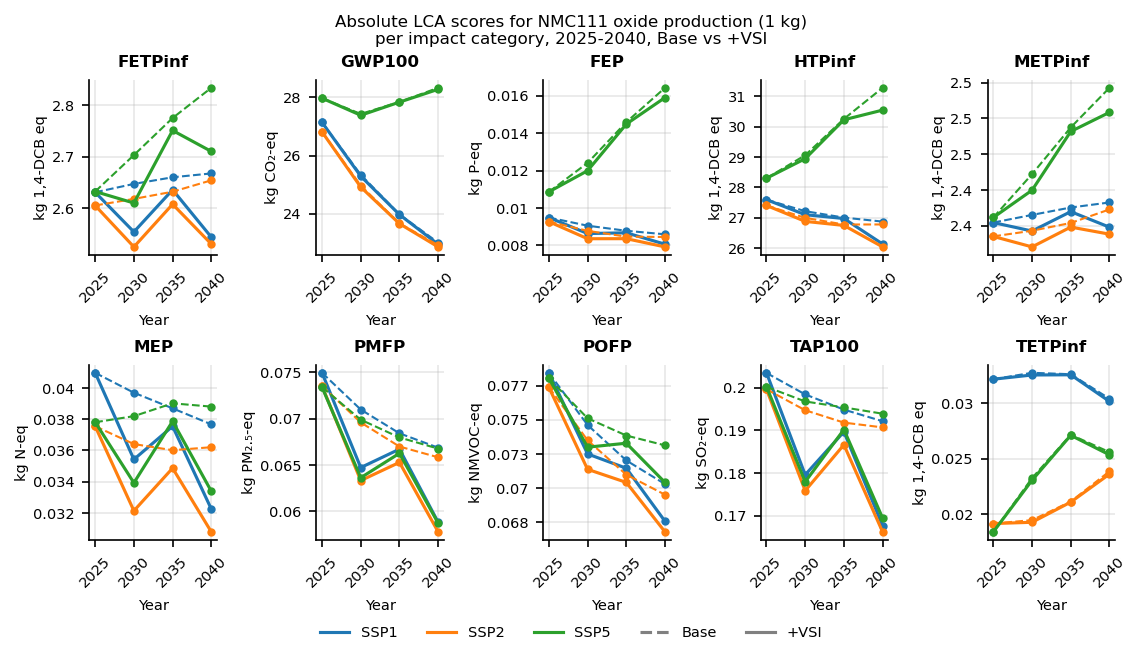

Figure 4 saved.


In [31]:
YEARS = [2025, 2030, 2035, 2040]
SSPS  = ["SSP1", "SSP2", "SSP5"]

fig, axes = plt.subplots(2, 5, figsize=(7.5, 3.8), constrained_layout=True)

for idx, cat in enumerate(VSI_AFFECTED):
    ax = axes.flatten()[idx]
    for ssp in SSPS:
        for scen, ls, lw in [("Base", "--", 1.0), ("VSI", "-", 1.5)]:
            sub = df_fig4[(df_fig4["IAM"] == ssp) & (df_fig4["Scenario"] == scen)]
            sub = sub.sort_values("Year")
            ax.plot(sub["Year"], sub[cat],
                    color=SSP_COLORS[ssp], linestyle=ls, linewidth=lw,
                    marker="o", markersize=3)
    ax.set_title(cat, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel(UNITS.get(cat, ""), labelpad=2)
    ax.set_xticks(YEARS)
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2g"))

legend_elements = [
    Line2D([0], [0], color=SSP_COLORS["SSP1"], lw=1.5, label="SSP1"),
    Line2D([0], [0], color=SSP_COLORS["SSP2"], lw=1.5, label="SSP2"),
    Line2D([0], [0], color=SSP_COLORS["SSP5"], lw=1.5, label="SSP5"),
    Line2D([0], [0], color="grey", lw=1.5, linestyle="--", label="Base"),
    Line2D([0], [0], color="grey", lw=1.5, linestyle="-",  label="+VSI"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.06), frameon=False)
fig.suptitle(
    "Absolute LCA scores for NMC111 oxide production (1 kg)\n"
    "per impact category, 2025-2040, Base vs +VSI",
    fontsize=8, y=1.06,
)

fig.savefig(OUTPUT_DIR / "Figure4_absolute_scores.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure4_absolute_scores.pdf",          bbox_inches="tight")
plt.show()
print("Figure 4 saved.")

---
## 3. Figure 5 — Relative Δ% from VSI: heatmap faceted by SSP

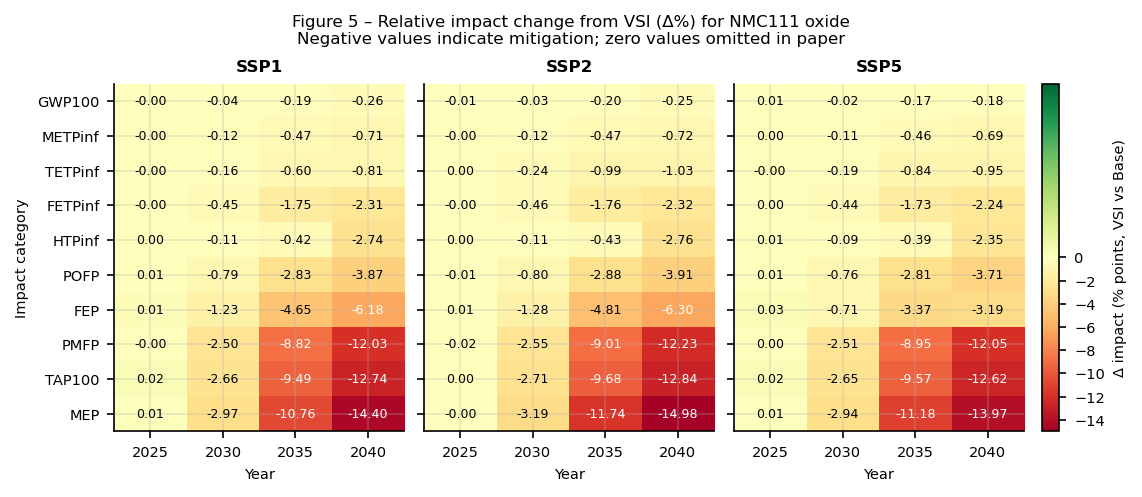

Figure 5 saved.


In [8]:
YEAR_COLS = [2025, 2030, 2035, 2040]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 3.2), constrained_layout=True)

vmax = df5[YEAR_COLS].abs().max().max()
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax * 0.05)
cmap = "RdYlGn"  # red = burden increase, green = mitigation

for ax, ssp in zip(axes, ["SSP1", "SSP2", "SSP5"]):
    sub = df5[df5["IAM"] == ssp].set_index("Impact")[YEAR_COLS]
    sub = sub.reindex(cat_order[::-1])  # most mitigated at top
    im  = ax.imshow(sub.values.astype(float), aspect="auto", cmap=cmap, norm=norm)

    for r in range(sub.shape[0]):
        for c in range(sub.shape[1]):
            val = sub.values[r, c]
            if not np.isnan(val):
                txt_color = "white" if abs(val) > vmax * 0.4 else "black"
                ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                        fontsize=6, color=txt_color)

    ax.set_xticks(range(len(YEAR_COLS)))
    ax.set_xticklabels(YEAR_COLS)
    ax.set_yticks(range(len(cat_order)))
    ax.set_yticklabels(cat_order[::-1] if ax == axes[0] else [])
    ax.set_title(ssp, fontweight="bold")
    ax.set_xlabel("Year")

axes[0].set_ylabel("Impact category")
cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("\u0394 impact (% points, VSI vs Base)", fontsize=7)
fig.suptitle(
    "Figure 5 – Relative impact change from VSI (\u0394%) for NMC111 oxide\n"
    "Negative values indicate mitigation; zero values omitted in paper",
    fontsize=8,
)

fig.savefig(OUTPUT_DIR / "Figure5_heatmap_VSI_delta.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure5_heatmap_VSI_delta.pdf",          bbox_inches="tight")
plt.show()
print("Figure 5 saved.")

---
## 4. Figure 6 — Process-level VSI mitigation: diverging bars by subsystem

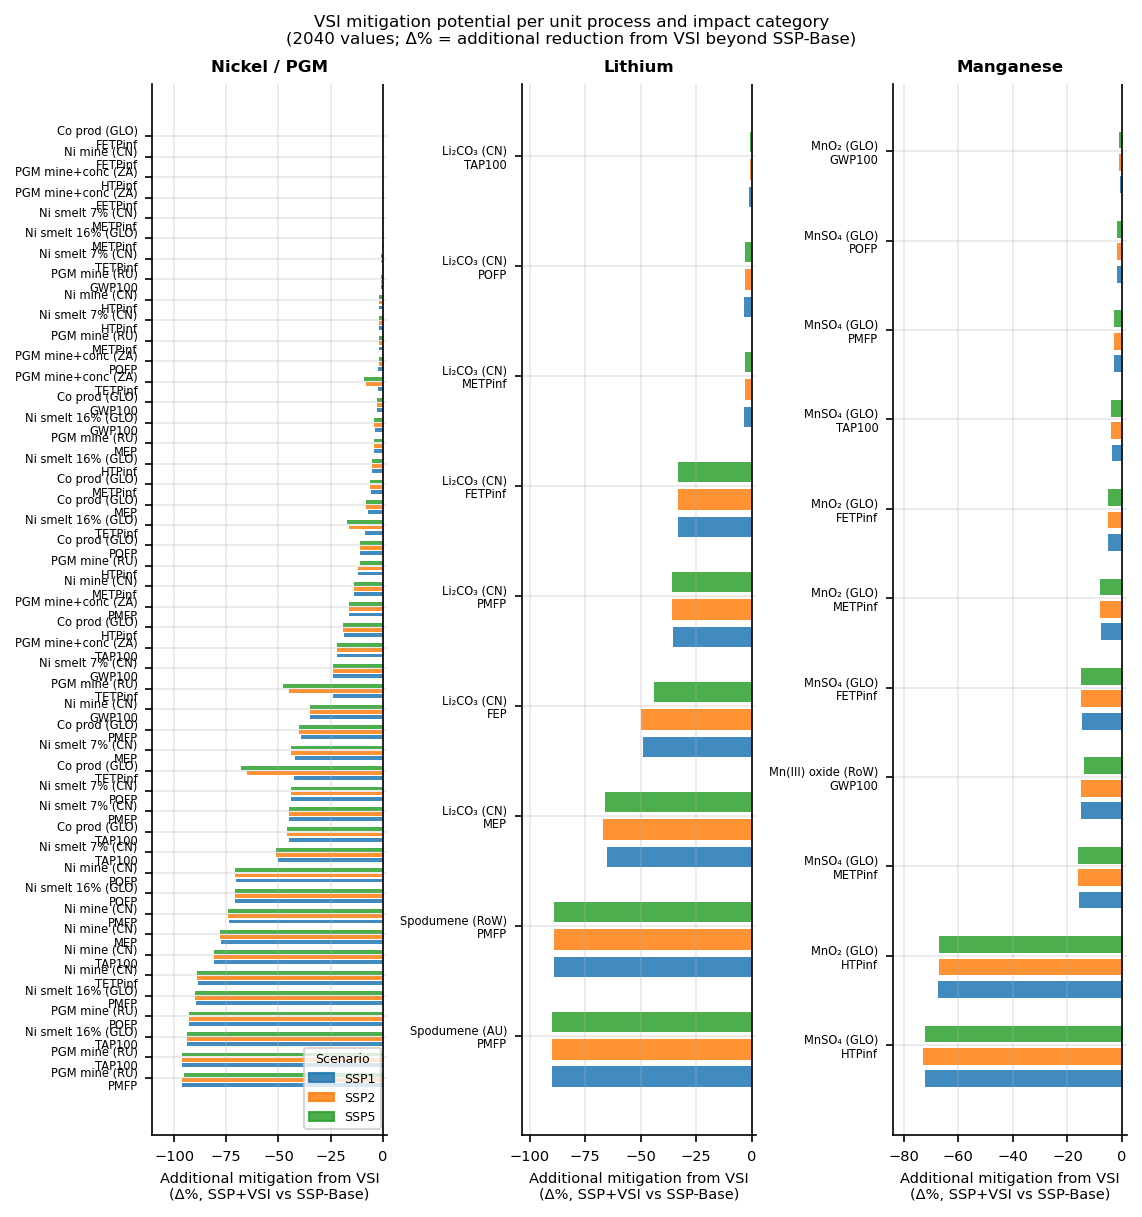

Figure 6 saved.


In [19]:
SUBSYSTEM_ORDER = ["Nickel / PGM", "Lithium", "Manganese"]
SSPS = ["SSP1", "SSP2", "SSP5"]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 8), constrained_layout=True)
BAR_HEIGHT = 0.15
BAR_GAP    = 0.05

for ax, subsys in zip(axes, SUBSYSTEM_ORDER):
    sub = df6_all[df6_all["subsystem"] == subsys].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    sub["label"] = sub["activity_short"] + "\n" + sub["impact"]
    labels = sub.groupby("label")["SSP1"].mean().sort_values().index.tolist()

    group_height = len(SSPS) * (BAR_HEIGHT + BAR_GAP)
    y_positions  = {lbl: i * (group_height + 0.2) for i, lbl in enumerate(labels)}

    for j, ssp in enumerate(SSPS):
        rows = sub.set_index("label")[ssp].reindex(labels)
        ys   = [y_positions[lbl] + j * (BAR_HEIGHT + BAR_GAP) for lbl in labels]
        ax.barh(ys, rows.values, height=BAR_HEIGHT,
                color=SSP_COLORS[ssp], alpha=0.85,
                label=ssp if ax == axes[0] else None)

    ytick_pos = [y_positions[lbl] + (len(SSPS) / 2) * (BAR_HEIGHT + BAR_GAP)
                 for lbl in labels]
    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(labels, fontsize=5.5)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Additional mitigation from VSI\n(\u0394%, SSP+VSI vs SSP-Base)")
    ax.set_title(subsys, fontweight="bold")
    xmin = sub[["SSP1", "SSP2", "SSP5"]].min().min() * 1.15
    xmax = max(sub[["SSP1", "SSP2", "SSP5"]].max().max() * 1.15, 2)
    ax.set_xlim(xmin, xmax)

handles = [plt.Rectangle((0, 0), 1, 1, color=SSP_COLORS[s], alpha=0.85) for s in SSPS]
axes[0].legend(handles, SSPS, title="Scenario",
               loc="lower right", fontsize=6, title_fontsize=6)
fig.suptitle(
    "VSI mitigation potential per unit process and impact category\n"
    "(2040 values; \u0394% = additional reduction from VSI beyond SSP-Base)",
    fontsize=8,
)

fig.savefig(OUTPUT_DIR / "Figure6_process_mitigation.png", dpi=300, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "Figure6_process_mitigation.pdf",          bbox_inches="tight")
plt.show()
print("Figure 6 saved.")

---
## 5. Optional: export as high-res TIFF (journal submission)

In [ ]:
# Uncomment and re-run figure cells above, then call:
# fig.savefig(OUTPUT_DIR / "Figure4.tiff", dpi=600, bbox_inches="tight")
# fig.savefig(OUTPUT_DIR / "Figure5.tiff", dpi=600, bbox_inches="tight")
# fig.savefig(OUTPUT_DIR / "Figure6.tiff", dpi=600, bbox_inches="tight")
print("TIFF export lines above — uncomment and re-run if needed.")